In [2]:
# Used Car Price Prediction
# Notebook: 02 - Data Cleaning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8')

In [4]:
df = pd.read_csv('../data/raw/car data.csv')

In [5]:
df_clean = df.copy()

In [6]:
print(f"Dataset loaded: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
df_clean.head()

Dataset loaded: 301 rows, 9 columns


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
# PART 1: CHECK FOR MISSING VALUES

In [8]:
for col in df_clean.columns:
    missing = df_clean[col].isnull().sum()
    pct = (missing / len(df_clean)) * 100
    dtype = df_clean[col].dtype
    print(f"{col:<20} | missing: {missing:>3} ({pct:.1f}%) | dtype: {dtype}")

Car_Name             | missing:   0 (0.0%) | dtype: str
Year                 | missing:   0 (0.0%) | dtype: int64
Selling_Price        | missing:   0 (0.0%) | dtype: float64
Present_Price        | missing:   0 (0.0%) | dtype: float64
Kms_Driven           | missing:   0 (0.0%) | dtype: int64
Fuel_Type            | missing:   0 (0.0%) | dtype: str
Seller_Type          | missing:   0 (0.0%) | dtype: str
Transmission         | missing:   0 (0.0%) | dtype: str
Owner                | missing:   0 (0.0%) | dtype: int64


In [9]:
# PART 2: CHECK FOR DUPLICATE ROWS

In [10]:
duplicates = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If there are duplicates, show them
if duplicates > 0:
    print("\nDuplicate rows:")
    print(df_clean[df_clean.duplicated(keep=False)])
    
    # Remove duplicates — keep the first occurrence
    df_clean = df_clean.drop_duplicates(keep='first')
    print(f"\nAfter removing duplicates: {df_clean.shape[0]} rows remain")
else:
    print("No duplicates found.")

Number of duplicate rows: 2

Duplicate rows:
    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
15    ertiga  2016           7.75          10.79       43000    Diesel   
17    ertiga  2016           7.75          10.79       43000    Diesel   
51  fortuner  2015          23.00          30.61       40000    Diesel   
93  fortuner  2015          23.00          30.61       40000    Diesel   

   Seller_Type Transmission  Owner  
15      Dealer       Manual      0  
17      Dealer       Manual      0  
51      Dealer    Automatic      0  
93      Dealer    Automatic      0  

After removing duplicates: 299 rows remain


In [11]:
# PART 3: FIX DATA TYPES

In [12]:
print("=== Current Data Types ===")
print(df_clean.dtypes)
print()

=== Current Data Types ===
Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object



In [13]:
print("=== Unique values in categorical columns ===\n")

cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
for col in cat_cols:
    print(f"{col}: {df_clean[col].unique()}")

=== Unique values in categorical columns ===

Fuel_Type: <ArrowStringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Seller_Type: <ArrowStringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission: <ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


In [14]:
# Fixing any case inconsistencies just to be safe

In [15]:
for col in cat_cols:
    df_clean[col] = df_clean[col].str.strip() 
    df_clean[col] = df_clean[col].str.title()  

print("Cleaned categorical values:")
for col in cat_cols:
    print(f"{col}: {df_clean[col].unique()}")

Cleaned categorical values:
Fuel_Type: <ArrowStringArray>
['Petrol', 'Diesel', 'Cng']
Length: 3, dtype: str
Seller_Type: <ArrowStringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission: <ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


In [16]:
print("=== Selling_Price Statistics ===\n")
print(df_clean['Selling_Price'].describe())
print(f"\nSkewness: {df_clean['Selling_Price'].skew():.2f}")

=== Selling_Price Statistics ===

count    299.000000
mean       4.589632
std        4.984240
min        0.100000
25%        0.850000
50%        3.510000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64

Skewness: 2.54


In [17]:
# Visualise the distribution

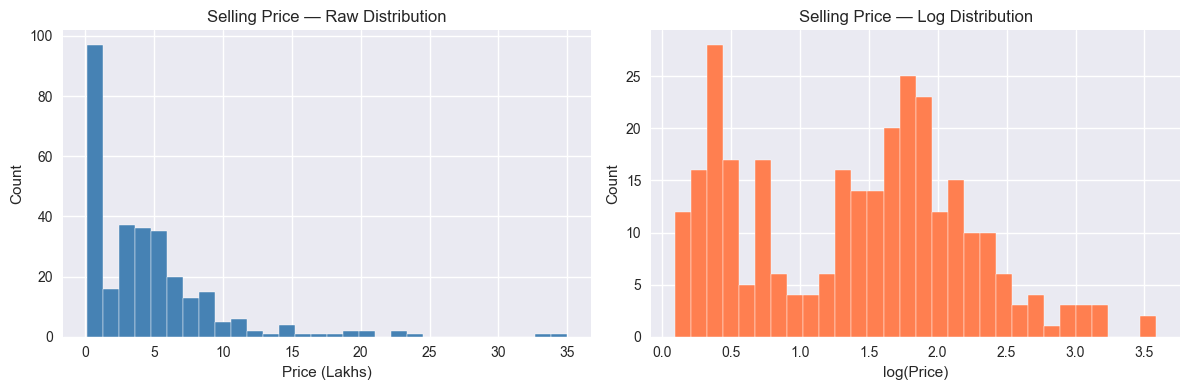


If skewness > 1.0, the data is right-skewed.
We may need to log-transform the target for better model performance.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Raw distribution
axes[0].hist(df_clean['Selling_Price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Selling Price — Raw Distribution')
axes[0].set_xlabel('Price (Lakhs)')
axes[0].set_ylabel('Count')

# Plot 2: Log distribution
axes[1].hist(np.log1p(df_clean['Selling_Price']), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Selling Price — Log Distribution')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/processed/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nIf skewness > 1.0, the data is right-skewed.")
print("We may need to log-transform the target for better model performance.")

In [21]:
# DETECT AND REMOVE OUTLIERS

In [22]:
def detect_outliers_iqr(dataframe, column):
    """
    Returns a boolean mask: True where a row IS an outlier.
    """
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_mask = (dataframe[column] < lower) | (dataframe[column] > upper)
    return outlier_mask, lower, upper

# Check numeric columns for outliers
numeric_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven']

print("=== Outlier Report ===\n")
for col in numeric_cols:
    mask, low, high = detect_outliers_iqr(df_clean, col)
    count = mask.sum()
    print(f"{col}:")
    print(f"  Valid range: {low:.2f} to {high:.2f}")
    print(f"  Outliers found: {count} rows ({count/len(df_clean)*100:.1f}%)\n")

=== Outlier Report ===

Selling_Price:
  Valid range: -6.88 to 13.73
  Outliers found: 16 rows (5.4%)

Present_Price:
  Valid range: -11.76 to 22.80
  Outliers found: 14 rows (4.7%)

Kms_Driven:
  Valid range: -35825.25 to 99708.75
  Outliers found: 8 rows (2.7%)



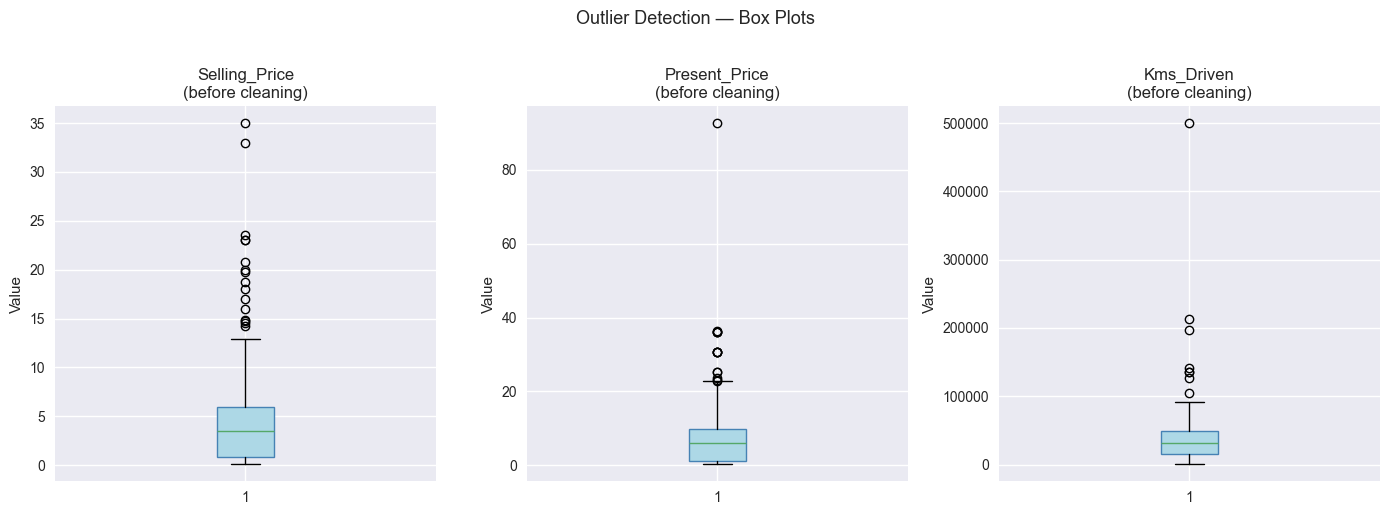

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='steelblue'))
    axes[i].set_title(f'{col}\n(before cleaning)')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection — Box Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/outliers_before.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
rows_before = len(df_clean)

kms_mask, kms_low, kms_high = detect_outliers_iqr(df_clean, 'Kms_Driven')
df_clean = df_clean[~kms_mask] 

rows_after = len(df_clean)
print(f"Rows removed as Kms_Driven outliers: {rows_before - rows_after}")
print(f"Dataset now has {rows_after} rows")

Rows removed as Kms_Driven outliers: 8
Dataset now has 291 rows


In [25]:
# FEATURE ENGINEERING — CAR AGE

In [26]:
import datetime

current_year = datetime.datetime.now().year
print(f"Current year: {current_year}")

# Create the Car_Age feature
df_clean['Car_Age'] = current_year - df_clean['Year']

print("\nSample — Year vs Car_Age:")
print(df_clean[['Car_Name', 'Year', 'Car_Age', 'Selling_Price']].head(10))

# Now drop the Year column — Car_Age is more informative
df_clean = df_clean.drop(columns=['Year'])

print(f"\nDropped 'Year'. New columns: {list(df_clean.columns)}")

Current year: 2026

Sample — Year vs Car_Age:
        Car_Name  Year  Car_Age  Selling_Price
0           ritz  2014       12           3.35
1            sx4  2013       13           4.75
2           ciaz  2017        9           7.25
3        wagon r  2011       15           2.85
4          swift  2014       12           4.60
5  vitara brezza  2018        8           9.25
6           ciaz  2015       11           6.75
7        s cross  2015       11           6.50
8           ciaz  2016       10           8.75
9           ciaz  2015       11           7.45

Dropped 'Year'. New columns: ['Car_Name', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


In [27]:
# DROP NON-USEFUL COLUMNS car name 

In [28]:
print(f"Unique car names: {df_clean['Car_Name'].nunique()}")
print("\nSample car names:")
print(df_clean['Car_Name'].value_counts().head(10))

# Drop Car_Name
df_clean = df_clean.drop(columns=['Car_Name'])
print(f"\nDropped 'Car_Name'. Remaining columns: {list(df_clean.columns)}")

Unique car names: 95

Sample car names:
Car_Name
city                         26
corolla altis                16
verna                        14
brio                         10
ciaz                          9
i20                           9
fortuner                      8
innova                        8
grand i10                     8
Royal Enfield Classic 350     7
Name: count, dtype: int64

Dropped 'Car_Name'. Remaining columns: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


In [29]:
# FINAL CLEAN DATASET SUMMARY

In [30]:
print("CLEANING COMPLETE — FINAL DATASET SUMMARY")

print(f"\nShape: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
print(f"\nColumns: {list(df_clean.columns)}")
print(f"\nData types:\n{df_clean.dtypes}")
print(f"\nMissing values:\n{df_clean.isnull().sum()}")
print(f"\nStatistical summary:")
df_clean.describe()

CLEANING COMPLETE — FINAL DATASET SUMMARY

Shape: 291 rows x 8 columns

Columns: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']

Data types:
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
Car_Age            int64
dtype: object

Missing values:
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Car_Age          0
dtype: int64

Statistical summary:


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,291.000000,291.000000,291.000000,291.000000,291.000000
mean,4.581031,7.354502,32591.312715,0.034364,12.219931
std,4.946487,8.379359,21496.425963,0.182477,2.696054
min,0.100000,0.320000,500.000000,0.000000,8.000000
25%,0.900000,1.200000,15000.000000,0.000000,10.000000
50%,3.650000,6.050000,31000.000000,0.000000,12.000000
75%,6.000000,9.400000,46140.000000,0.000000,14.000000
max,35.000000,92.600000,92233.000000,1.000000,23.000000


In [31]:
# saving to the processed folder 

In [32]:
df_clean.to_csv('../data/processed/car_data_cleaned.csv', index=False)

print("Cleaned dataset saved to: data/processed/car_data_cleaned.csv")
print(f"Final shape: {df_clean.shape}")

Cleaned dataset saved to: data/processed/car_data_cleaned.csv
Final shape: (291, 8)
